## ***Data Science Internship Task 4***

In [3]:
# Step 1: Library Imports & Data Collection
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [4]:
# Load your dataset (Replace 'WA_Fn-UseC_-Telco-Customer-Churn.csv' with your actual file path)
df = pd.read_csv('Telco-Customer-Churn.csv')

print("Data Shape:", df.shape)
display(df.head())

Data Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Step 2: Data Preprocessing
# Drop CustomerID as it's a unique identifier, not a feature
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)

# Convert TotalCharges to numeric, handling potential blank spaces by coercing to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Handle missing values by filling them (e.g., with median)
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Encode target variable 'Churn' (Yes/No to 1/0)
if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Encode categorical variables using one-hot encoding
df = pd.get_dummies(df, drop_first=True)

/tmp/ipykernel_2276/2637347405.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


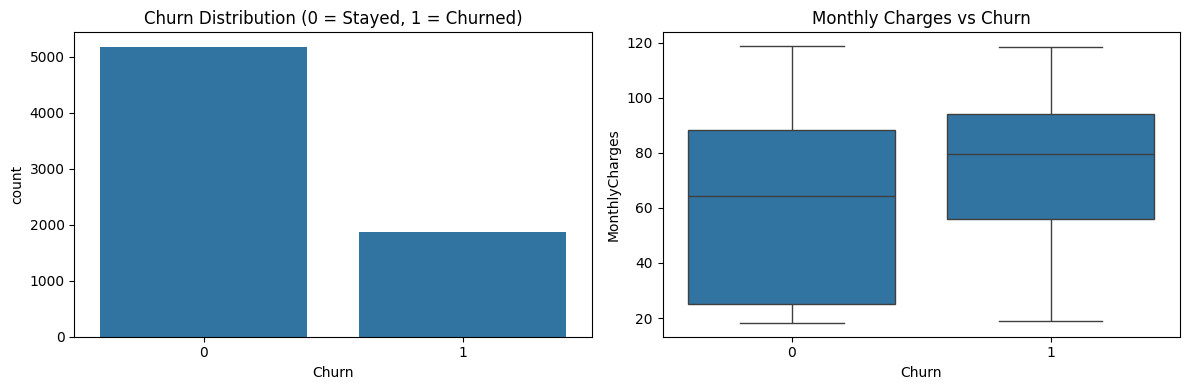

In [6]:
# Step 3: Exploratory Data Analysis (EDA) & Visualizations
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Churn')
plt.title('Churn Distribution (0 = Stayed, 1 = Churned)')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges vs Churn')

plt.tight_layout()
plt.show()

In [7]:
# Step 4: Feature Engineering & Data Splitting
X = df.drop(columns=['Churn'])
y = df['Churn']

# Split dataset into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Random Forest Classifier

In [8]:
# Step 5: Model Building & Training (Random Forest Classifier recommended)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

In [9]:
# Step 6: Model Evaluation
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)

Accuracy: 0.7892
Precision: 0.6429
Recall: 0.4584
F1 Score: 0.5352

Confusion Matrix:
[[941  95]
 [202 171]]


### Logistic Regression Classifier

In [10]:
# Step 5: Model Building & Training using Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Using a pipeline to automatically scale data and apply Logistic Regression
model = make_pipeline(StandardScaler(), LogisticRegression(random_state=42))
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)


# Step 6: Model Evaluation
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Logistic Regression Accuracy: {acc:.4f}")
print(f"Logistic Regression Precision: {prec:.4f}")
print(f"Logistic Regression Recall: {rec:.4f}")
print(f"Logistic Regression F1 Score: {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)

Logistic Regression Accuracy: 0.8197
Logistic Regression Precision: 0.6831
Logistic Regression Recall: 0.5952
Logistic Regression F1 Score: 0.6361

Confusion Matrix:
[[933 103]
 [151 222]]


### Decision Tree Classifier

In [12]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Decision Tree Accuracy: {acc:.4f}")
print(f"Decision Tree Precision: {prec:.4f}")
print(f"Decision Tree Recall: {rec:.4f}")
print(f"Decision Tree F1 Score: {f1:.4f}")

Decision Tree Accuracy: 0.7097
Decision Tree Precision: 0.4519
Decision Tree Recall: 0.4531
Decision Tree F1 Score: 0.4525
